In [73]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], dtype=float)
y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3], dtype=float)





In [74]:
# A1
import numpy as np
import matplotlib.pyplot as plt

# Thomas Algorithm
def thomas_algorithm(a, b, c, d):
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x


#get the second derivatives
def getM(x, y):
    n = len(x)
    h = np.diff(x)

    A = np.zeros(n-2)
    B = np.zeros(n-2)
    C = np.zeros(n-2)
    D = np.zeros(n-2)

    for i in range(1, n-1):
        A[i-1] = h[i-1]
        B[i-1] = 2*(h[i-1] + h[i])
        C[i-1] = h[i]
        D[i-1] = 6*((y[i+1]-y[i])/h[i] - (y[i]-y[i-1])/h[i-1])

    M_inner = thomas_algorithm(A, B, C, D)
    M = np.concatenate(([0], M_inner, [0])) 

    return M


# the spline at 1 x 
def spline_eval(x, y, M, xval):
    i = np.searchsorted(x, xval) - 1
    i = np.clip(i, 0, len(x)-2)

    h = x[i+1] - x[i]

    term1 = (M[i]/(6*h)) * (x[i+1]-xval)**3
    term2 = (M[i+1]/(6*h)) * (xval-x[i])**3
    term3 = (y[i]/h - (M[i]*h)/6) * (x[i+1]-xval)
    term4 = (y[i+1]/h - (M[i+1]*h)/6) * (xval-x[i])

    return term1 + term2 + term3 + term4


M = getM(x, y)

"""
Since there are 20 data points, the amount of unknowns is 18 .
The system is a 18 x 18 tridiagonal system.
The continuity conditions at each interior knot are 
continuity of the function, the first derivative, and the second derivative.
The boundary conditions are that the second derivative at the endpoints will be zero.
"""

'\nSince there are 20 data points, the amount of unknowns is 18 .\nThe system is a 18 x 18 tridiagonal system.\nThe continuity conditions at each interior knot are \ncontinuity of the function, the first derivative, and the second derivative.\nThe boundary conditions are that the second derivative at the endpoints will be zero.\n'

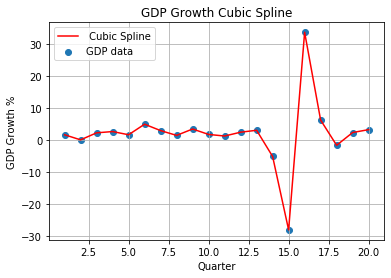

'\nDue to the method of evaluation, the graph is continious, so it looks visually smooth. \nThe spike about the Covid data makes sense, and is economically realistic. \nThis seems reasonable as it is visually smooth, and accounts for the Covid data. \n'

In [75]:
#A2
#plot
x_full = np.arange(1, 21)
y_full_spline = np.zeros(len(x_full))

for i in range(len(x_full)):
    y_full_spline[i] = spline_eval(x, y, M, x_full[i])

plt.scatter(x, y, label="GDP data")
plt.plot(x_full, y_full_spline, label=" Cubic Spline", color='red')
plt.xlabel("Quarter")
plt.ylabel("GDP Growth %")
plt.title("GDP Growth Cubic Spline")
plt.legend()
plt.grid()
plt.show()

"""
Due to the method of evaluation, the graph is continious, so it looks visually smooth. 
The spike about the Covid data makes sense, and is economically realistic. 
This seems reasonable as it is visually smooth, and accounts for the Covid data. 
"""

In [76]:
#A3
"""

According to lecture 14 Runge's phenomenon is when high degree polynomials oscillate wildly at the edges of the data range. 
Polynomial fitting to the degree n-1 will overfit and oscillate. 
Exact interpolation means the curve passes through every data point exactly. 
The trade off while prioritizing this is while the fit at the points is perfect, outliers can cause unrealistic graphs. 
Numerical stability is the property of a algorithm that makes sure that erorrs don't propogate and balloon out. 
If Numerical stability is prioritized, the graph will make more sense, but it will be less accurate. 
Smoothing splines or weighted least squares would be preferable as it would minimize the effect of the Covid data. 

"""

"\n\nAccording to lecture 14 Runge's phenomenon is when high degree polynomials oscillate wildly at the edges of the data range. \nPolynomial fitting to the degree n-1 will overfit and oscillate. \nExact interpolation means the curve passes through every data point exactly. \nThe trade off while prioritizing this is while the fit at the points is perfect, outliers can cause unrealistic graphs. \nNumerical stability is the property of a algorithm that makes sure that erorrs don't propogate and balloon out. \nIf Numerical stability is prioritized, the graph will make more sense, but it will be less accurate. \nSmoothing splines or weighted least squares would be preferable as it would minimize the effect of the Covid data. \n\n"

B1:
Degree 4 MSE = 99.30773796212381
Degree 4 R^2 = 0.016632392138783647
Condition number of V = 482958.7228354322
Degree 4 RMSE = 9.965326786519537


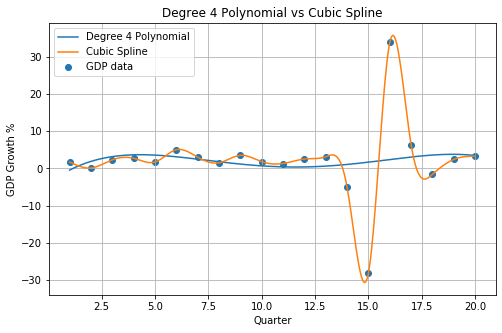

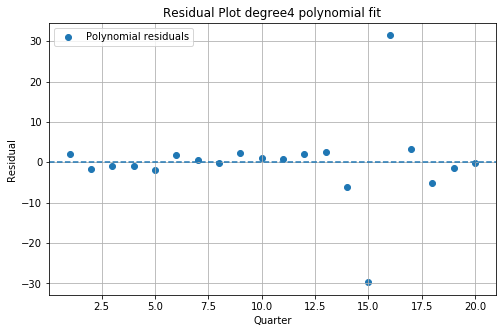

'\nThe degree 4 Polynomial gives a better idea of what the trend actually is. \nThe cubic spline is better at reproducing specific data points. \nThe trade off is a more accurate trend vs more accurate specific data points. \n\n'

In [77]:
#B1
# errors tools calculated
def mse(y, y_p):
    return np.mean((y - y_p)**2)

def r_sq(y, y_p):
    ss_tot = np.sum((y - np.mean(y))**2)
    ss_res = np.sum((y - y_p)**2)
    return 1 - ss_res/ss_tot

x_plot = np.linspace(x.min(), x.max())
# vandermonde matrix
def vandermonde_matrix(x, degree):
    n = len(x)
    V = np.zeros((n, degree + 1))
    for i in range(n):
        for j in range(degree + 1):
            V[i, j] = x[i]**(degree - j)
    return V

#least square
def custom_ls(x, y):
    n = len(x)
    sx = np.sum(x)
    sy = np.sum(y)
    sxx = np.sum(x * x)
    sxy = np.sum(x * y)

    m = (n * sxy - sx * sy) / (n * sxx - sx * sx)
    b = (sy / n) - m * (sx / n)

    return m, b


degree = 4
V = vandermonde_matrix(x, degree)

#normal equations
coef = np.linalg.solve(V.T @ V, V.T @ y)

Y_poly = V @ coef
x_plot = np.linspace(x.min(), x.max(), 400)
Vp = vandermonde_matrix(x_plot, degree)
y_plot = Vp @ coef

# spline comparition
y_spline_plot = np.zeros(len(x_plot))
for i in range(len(x_plot)):
    y_spline_plot[i] = spline_eval(x, y, M, x_plot[i])

print("B1:")
print("Degree 4 MSE =", mse(y, Y_poly))
print("Degree 4 R^2 =", r_sq(y, Y_poly))
print("Condition number of V =", np.linalg.cond(V))
rmse = np.sqrt(mse(y, Y_poly))
print("Degree 4 RMSE =", rmse)
plt.figure(figsize=(8,5))
plt.scatter(x, y, label="GDP data")
plt.plot(x_plot, y_plot, label="Degree 4 Polynomial")
plt.plot(x_plot, y_spline_plot, label="Cubic Spline")
plt.xlabel("Quarter")
plt.ylabel("GDP Growth %")
plt.title("Degree 4 Polynomial vs Cubic Spline")
plt.legend()
plt.grid()
plt.show()

# Residual plot required by midterm
poly_residuals = y - Y_poly

plt.figure(figsize=(8,5))
plt.scatter(x, poly_residuals, label="Polynomial residuals")
plt.axhline(0, linestyle='--')
plt.xlabel("Quarter")
plt.ylabel("Residual")
plt.title("Residual Plot degree4 polynomial fit")
plt.legend()
plt.grid()
plt.show()


"""
The degree 4 Polynomial gives a better idea of what the trend actually is. 
The cubic spline is better at reproducing specific data points. 
The trade off is a more accurate trend vs more accurate specific data points. 

"""

Slope: -0.0173364485981308
Intercept: 2.3041121495327097
Degree 4 RMSE = 9.965326786519537


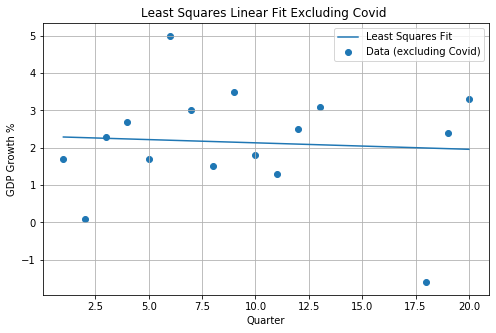

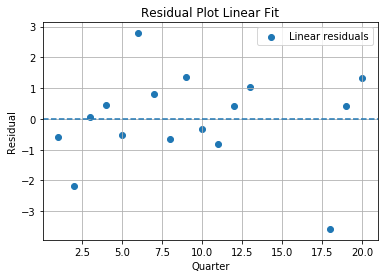

"\nI got that the slope was -0.0173364485981308. \nLinear doesn't work well because ther is not much of a corelarion between the line\nand the data, a oscillating trend makes more sense. \nA linear model requires the assumption that the data is stable and linear when removing the covid data. \n"

In [78]:
# B2
#lest squares

def custom_ls(x, y):
    n = len(x)
    sx = np.sum(x)
    sy = np.sum(y)
    sxx = np.sum(x*x)
    sxy = np.sum(x*y)

    m = (n*sxy - sx*sy) / (n*sxx - sx*sx)
    b = (sy/n) - m*(sx/n)

    return m, b

# excluding the covid data
mask = np.array([True, True, True, True, True,
                 True, True, True, True, True,
                 True, True, True, False, False,
                 False, False, True, True, True])

x_no_covid = x[mask]
y_no_covid = y[mask]

m, b = custom_ls(x_no_covid, y_no_covid)

res = y_no_covid - (m*x_no_covid + b)
print("Slope:", m)
print("Intercept:", b)
print("Degree 4 RMSE =", rmse)
plt.figure(figsize=(8,5))
plt.scatter(x_no_covid, y_no_covid, label="Data (excluding Covid)")
plt.plot(x_no_covid, m*x_no_covid + b, label="Least Squares Fit")
plt.xlabel("Quarter")
plt.ylabel("GDP Growth %")
plt.title("Least Squares Linear Fit Excluding Covid ")
plt.legend()
plt.grid()

plt.figure()
plt.scatter(x_no_covid, res, label="Linear residuals")
plt.axhline(0, linestyle='--')
plt.xlabel("Quarter")
plt.ylabel("Residual")
plt.title("Residual Plot Linear Fit")
plt.legend()
plt.grid()
plt.show()

"""
I got that the slope was -0.0173364485981308. 
Linear doesn't work well because ther is not much of a corelarion between the line
and the data, a oscillating trend makes more sense. 
A linear model requires the assumption that the data is stable and linear when removing the covid data. 
"""

In [79]:
#C1

"""
For a policy maker I'd recomend the cubic spline method, due to its accuracy and estimations in between, with one caveat- to exclude the covid data. 
The drawback of the sensitivity of the cubic spline method would be counteracted by the removal of the outlier covid data. 
The spline is more smooth and accurate, and preserves the continuity of the funtion up till the second derivative. 
"""

#C added
"""
Big O describes how runtime increases as input size (n) increases. The degree-4 polynomial fit has big O of O(n) becasuse the degree is fixed. The 
cubic spline method is O(n^2) because of the matrix. This further pursuades me to recomend the cubic spline due to its time complexity. 
"""

'\nBig O describes how runtime increases as input size (n) increases. The degree-4 polynomial fit has big O of O(n) becasuse the degree is fixed. The \ncubic spline method is O(n^2) because of the matrix. This further pursuades me to recomend the cubic spline due to its time complexity. \n'

# Report #


This project is about analyzing U.S. quarterly GDP data using different numerical tools. These tools, namely, are cubic spline interpolation, degree 4 polynomial least squares fitting, and linear least squares regression. The data consists of 20 GDP data points collected quarterly. The goal is to compare the methods, and find out which method is better for modeling. 

   The cubic spline was made using a tridiagonal system with 18 unknowns. It is a continuous function up till the second derivative. Since it is continuous, as well as the nature of this function, the plot is visually smooth. There's a tradeoff, however, with the outliers or the covid data which is shown in the sharp curvature at -28.1 and 33.8. This extreme behavior with outliers is one of the limitations of this model which can also be connected to Runge's phenomenon. Removing the outliers or smoothing the data might be beneficial for this model. 
   
   The degree 2 polynomial fit and cubic spline were compared using both quantative methods, and graphing. The polynomial fit has a RMSE of about 9.97, R^2 of 0.0166, and a condition number aboout 482959. The RMSE is relatively large, showing the polynomial fit does not fit the data well. The low R^2 data also supports this claim. The high condition number also shows that Matrix is ill-conditioned which implies the data is more sensitive which means it is less reliable. 
    
   The graph that shows a better general trend is the polynomial fit. In contrast the cubic spline is better with the specifics of the data points. This contrast also demonstrates the difference between approximation and interpolation, showing that for a better general trend (or approximation) you lose accuracy and vice versa.
In the least squares model even after removing outlier data the trend was too general. For the least squares model the Covid data was excluded to have a better idea of the trend. The slope found was about -0.0173. It's close to zero and indicates lack of a strong linear relationship. This shows that a linear trend does not make much sense for this data, with perhaps an oscillating function a contender for a better fit. 

   Based on both quantitative and qualitative analysis, the cubic spline is the better method, and what I'd recommend to a policymaker who needs to estimate GDP growth. The cubic spline is smooth and continuous, which also makes it suited to a policy maker who needs to figure out intermediate and future values. The cubic spline has a caveat with outliers, however it is possible to remove them. The degree 4 polynomial shows a approximation which is smoother but is less accurate. The metrics which include the RMSE, R^2, and slope show a lot of inaccuracy, which shows that the degree 4 polynomial fit isn't the bet fit. The linear least square is less accurate that either of the previous two. It has an even higher RMSE of about 9.9 as well as an general or also inconclusive slope. To top it off using the big O analysis, shows cubic spline has a better time complexity than the degree 4 polynomial fit. 
   
   In conclusion, out of all of the three methods the cubic spline, degree 4 polynomial, and linear least squares method, the cubic spline performed the best. It reproduced the data and was continuous and smooth throughout the graph. The degree 4 polynomial captured a general trend but its quality was not the best. The linear model had the worst fit and was the least effective. The cubic fit was the best because of its accuracy and also the purpose of assisting the policymaker. A different method may be more effective depending on the scenario, and for this one the cubic spline was the best one. 